<a href="https://colab.research.google.com/github/dr-koehler-ai/Heart-Failure-Clinical-Records-Dashboard-V1/blob/main/Heart_Failure_Clinical_Records_Dashboard_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Heart Failure Survival Prediction**

*Objective*

*   Predict Mortality using clinical variables

*Dataset*
*   299 patients
*   13 clinical features
*   binary outcome (target variable: death event)


*Workflow*
*   Data cleaning
*   EDA
*   Statistical Analysis
*   Logistic Regression
*   Machine Learning

*Clinical question*

Can routinely available clinical variables predict mortality in heart failure patients?

In [40]:
# Heart Failure Clinical Records Dashboard (V1)
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Statistics
from scipy import stats
from statistics import mean, stdev
from math import sqrt

# Data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Data modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# =========================
# 1. Dataset Download
# =========================

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_failure_clinical_records = fetch_ucirepo(id=519)

# data (as pandas dataframes)
X = heart_failure_clinical_records.data.features
y = heart_failure_clinical_records.data.targets

# metadata
print(heart_failure_clinical_records.metadata)

# variable information
print(heart_failure_clinical_records.variables)

# adding death_event as variable
heart_failure_clinical_records = pd.DataFrame(X)
heart_failure_clinical_records["death_event"] = y

{'uci_id': 519, 'name': 'Heart Failure Clinical Records', 'repository_url': 'https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records', 'data_url': 'https://archive.ics.uci.edu/static/public/519/data.csv', 'abstract': 'This dataset contains the medical records of 299 patients who had heart failure, collected during their follow-up period, where each patient profile has 13 clinical features.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 299, 'num_features': 12, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['death_event'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5Z89R', 'creators': [], 'intro_paper': {'ID': 286, 'type': 'NATIVE', 'title': 'Machine learning can predict survival of patients with heart failure f

**2. Dataset Overview**


*   Number of rows and columns
*   Basic statistics



In [3]:
# =========================
# 2. Dataset Overview
# =========================

print("Number of rows and columns:", heart_failure_clinical_records.shape)
print("Overview:", heart_failure_clinical_records.describe())
print("Variables:", heart_failure_clinical_records.columns.to_list())
print("Table Head:",heart_failure_clinical_records.head(10))


Number of rows and columns: (299, 13)
Overview:               age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.00

**3. Missing Data Analysis and Checking for Duplicates**

No missing values and no duplicates were detected. Therefore, no imputation was required before further statistical analysis.

In [20]:
# =========================
# 3. Missing Data Analysis
# =========================

missing = heart_failure_clinical_records.isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(15))
print("There are no missing values")

print(heart_failure_clinical_records.duplicated().sum())
print("There are no duplicates")


Top Missing Values:
 age                         0.0
anaemia                     0.0
creatinine_phosphokinase    0.0
diabetes                    0.0
ejection_fraction           0.0
high_blood_pressure         0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
sex                         0.0
smoking                     0.0
time                        0.0
death_event                 0.0
dtype: float64
There are no missing values
0
There are no duplicates


**Exploratory Data Analysis**



**4. Analysis of Target Variable**


*   unbalanced distribution of target variable



Outcome distribution:
death_event
0    203
1     96
Name: count, dtype: int64
Mortality rate: 32.1%


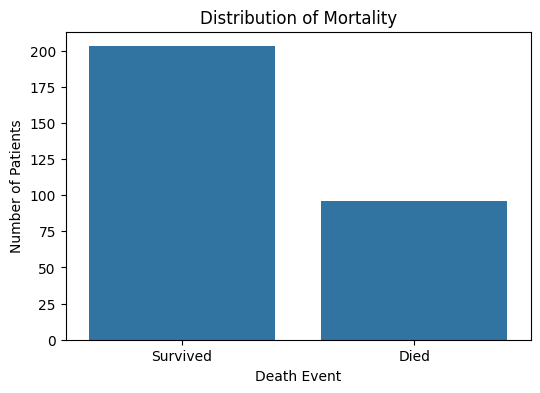

In [2]:
# =========================
# 4. Target Variable
# =========================

print("Outcome distribution:")
print(heart_failure_clinical_records["death_event"].value_counts())
mortality_rate = heart_failure_clinical_records["death_event"].mean()

print(f"Mortality rate: {mortality_rate:.1%}")
plt.figure(figsize=(6,4))

sns.countplot(
    data=heart_failure_clinical_records,
    x="death_event"
)

plt.title("Distribution of Mortality")
plt.xlabel("Death Event")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Survived", "Died"])
plt.show()

**5. Univariate Analysis of Continuous Variables**


*   Histogramms
*   Boxplots
*   EDA was focused on clinical relevance and role in pathophysiology of heart insufficiency, therefore serum sodium was excluded.


*Key Findings:*

*   Patients with fatal outcomes showed lower ejection fraction.
*   Higher serum creatinine levels were observed among patients who died.
*   Age appeared higher among non-survivors.

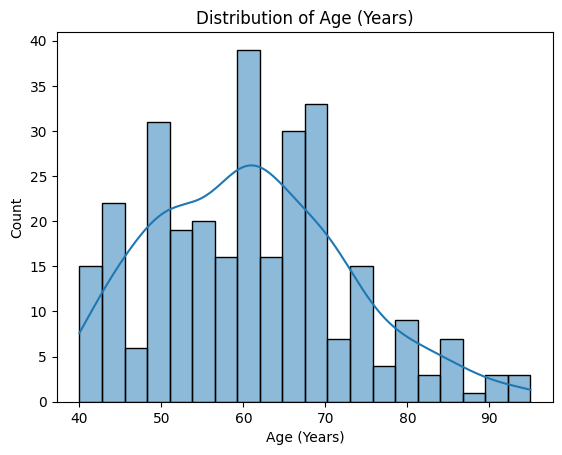

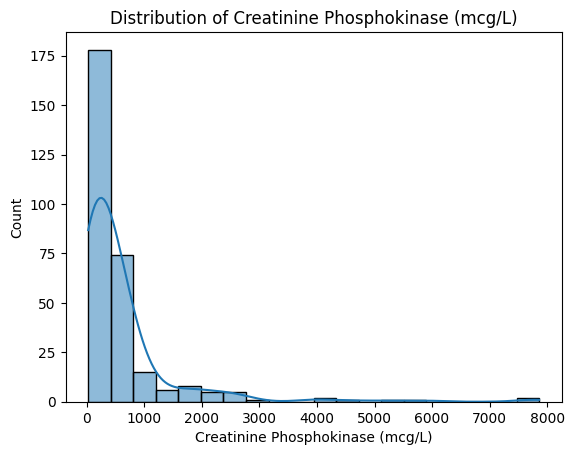

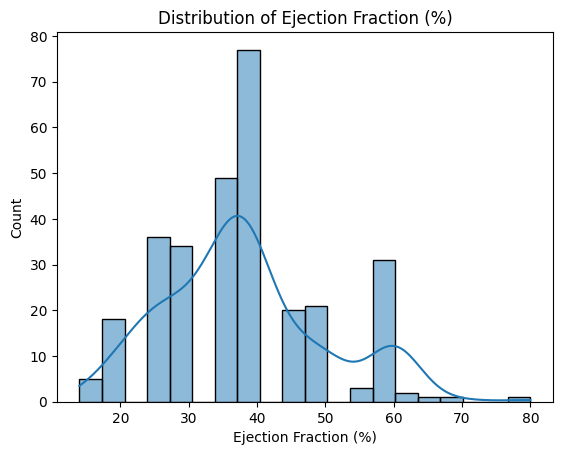

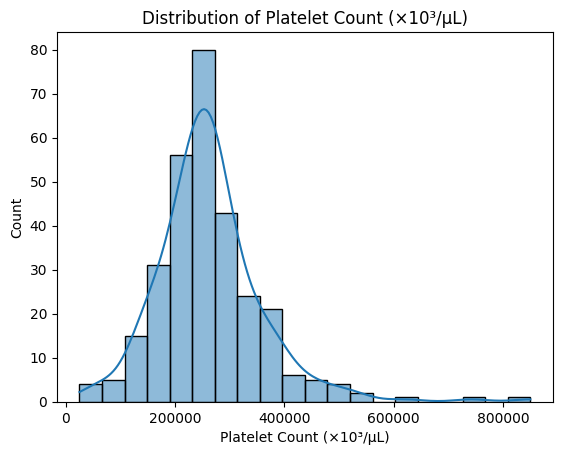

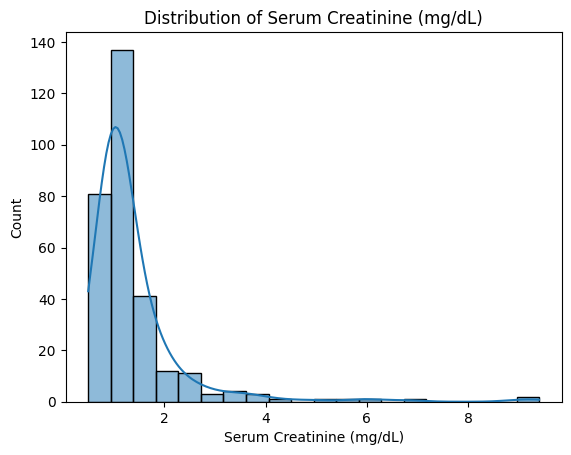

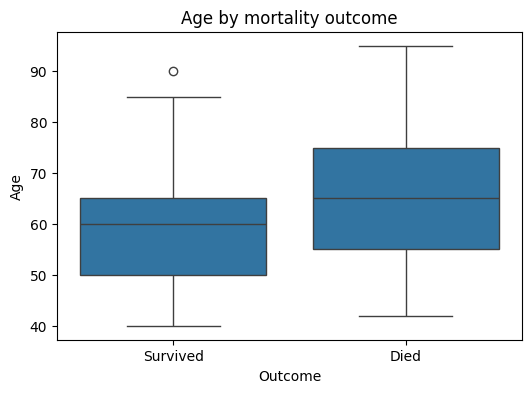

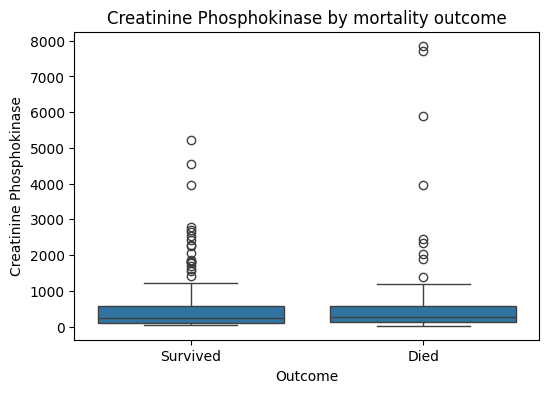

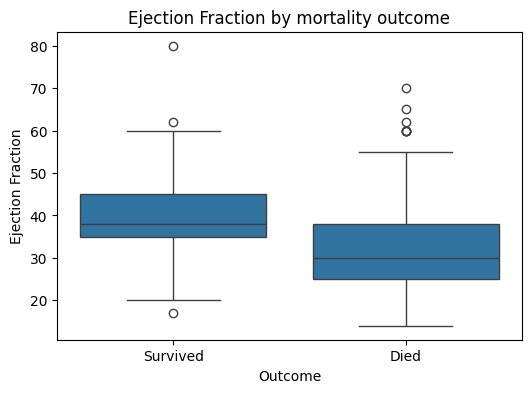

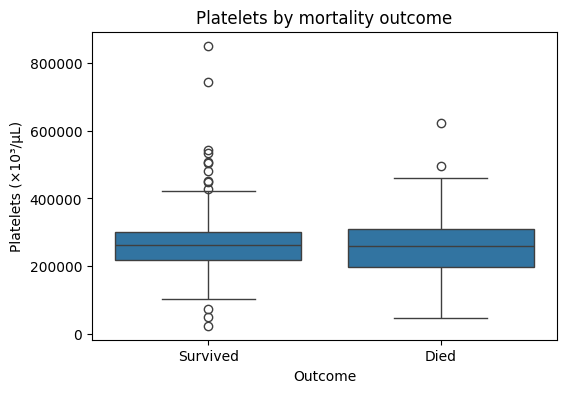

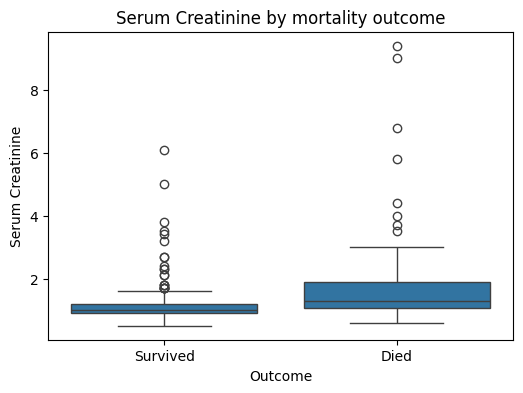

In [27]:
# ==================================================
# 5. Univariate Analysis of Continuous variables
# ==================================================
continuous_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
]

variable_labels = {
    "age": "Age (Years)",
    "creatinine_phosphokinase": "Creatinine Phosphokinase (mcg/L)",
    "ejection_fraction": "Ejection Fraction (%)",
    "platelets": "Platelet Count (×10³/µL)",
    "serum_creatinine": "Serum Creatinine (mg/dL)"
}

def var_histograms(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    fig = sns.histplot(data=heart_failure_clinical_records, x=feat, bins=20, kde=True)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.show()
  return

var_histograms(continuous_features)

for feature in continuous_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=heart_failure_clinical_records,
        x="death_event",
        y=feature
    )

    plt.xticks(
        [0,1],
        ["Survived", "Died"]
    )

    plt.title(f"{feature.replace('_', ' ').title()} by mortality outcome")
    plt.xlabel("Outcome")

    if feature == "platelets":
        plt.ylabel("Platelets (×10³/µL)")
        plt.ticklabel_format(
            style="plain",
            axis="y"
        )
    else:
        plt.ylabel(feature.replace('_', ' ').title())

    plt.show()

**6. Univariate Analysis of Binary Variables**


*   Barplot



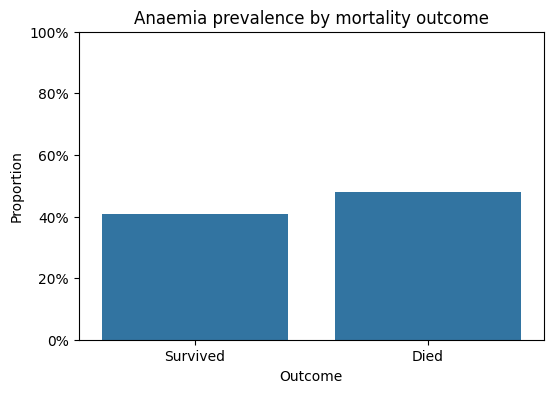

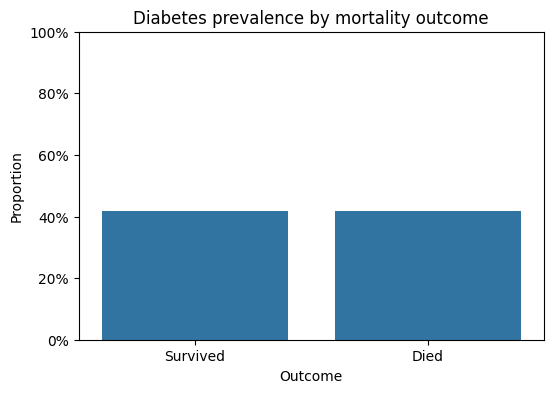

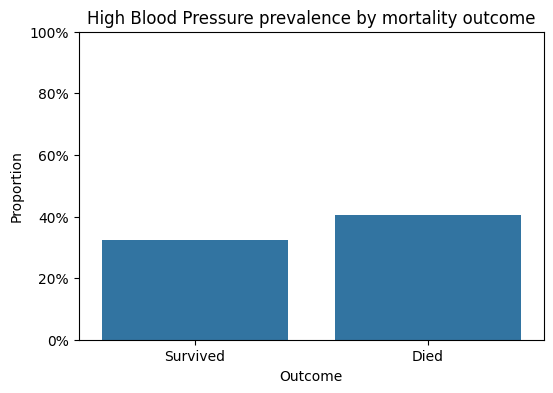

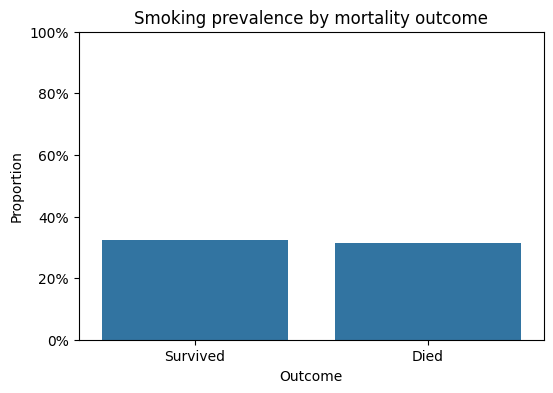

In [ ]:
# ==================================================
# 6. Univariate Analysis of Binary variables
# ==================================================

categorical_features = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "smoking"
]

import matplotlib.ticker as mtick

for feature in categorical_features:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=heart_failure_clinical_records,
        x="death_event",
        y=feature,
        errorbar=None
    )

    plt.xticks(
        [0,1],
        ["Survived", "Died"]
    )

    plt.title(f"{feature.replace('_', ' ').title()} prevalence by mortality outcome")
    plt.xlabel("Outcome")
    plt.ylabel("Proportion")
    plt.ylim(0,1)
    plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

    plt.show()

**7. Statistical Analysis**


*   Checking for siginificant differences in relevant groups
*   2-Sample T-Test and Mann-Whitney-U-Test for continuous variables
*   Chi-Square-Test for categorical variables
*   Cohen's d
* As multiple univariate tests were performed, p-values should be interpreted cautiously. No formal multiple-testing correction was applied because this analysis is exploratory.



In [33]:
# =========================
# 7. Statistical Analysis
# =========================

continuous_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
]

non_normal_features = [
    "creatinine_phosphokinase",
    "serum_creatinine"
]

categorical_features = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "smoking"
]

death_patients = heart_failure_clinical_records[heart_failure_clinical_records["death_event"] == 1]
non_death_patients = heart_failure_clinical_records[heart_failure_clinical_records["death_event"] == 0]


def compare_groups(features, test_name="welch"):

    print(f"\n{'='*60}")
    print(f"{test_name.upper()} TEST")
    print(f"{'='*60}")

    for feature in features:

        group1 = death_patients[feature].dropna()
        group2 = non_death_patients[feature].dropna()

        if test_name == "welch":
            statistic, p_value = stats.ttest_ind(
                group1,
                group2,
                equal_var=False
            )

        elif test_name == "mannwhitney":
            statistic, p_value = stats.mannwhitneyu(
                group1,
                group2,
                alternative="two-sided"
            )

        print(
            f"{feature:<20}"
            f"Statistic = {statistic:>10.2f}"
            f"   p = {p_value:.3e}"
        )
def compare_categorical(features):

    print(f"\n{'='*60}")
    print("CHI-SQUARE TEST")
    print(f"{'='*60}")

    for feature in features:

        table = pd.crosstab(
            heart_failure_clinical_records[feature],
            heart_failure_clinical_records["death_event"]
        )

        chi2, p_value, dof, expected = stats.chi2_contingency(table)

        print(
            f"{feature:<25}"
            f"Chi2={chi2:>10.2f}"
            f" p={p_value:.3e}"
        )

def cohens_d(features):

    print(f"\n{'='*60}")
    print("Cohens D")
    print(f"{'='*60}")

    for feature in features:

      group1 = death_patients[feature].dropna()
      group2 = non_death_patients[feature].dropna()

      n1, n2 = len(group1), len(group2)
      var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

      # Pooled standard deviation
      pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

      # Cohen's d formula
      effect_size = (np.mean(group1) - np.mean(group2)) / pooled_std

      print(
            f"{feature:<20}"
            f"Cohens D = {effect_size:>10.2f}"
        )

    return


compare_groups(continuous_features, test_name="welch")
compare_groups(non_normal_features, test_name="mannwhitney")
compare_categorical(categorical_features)
cohens_d(continuous_features)


WELCH TEST
age                 Statistic =       4.19   p = 4.735e-05
creatinine_phosphokinaseStatistic =       0.90   p = 3.692e-01
ejection_fraction   Statistic =      -4.57   p = 9.647e-06
platelets           Statistic =      -0.84   p = 3.993e-01
serum_creatinine    Statistic =       4.15   p = 6.399e-05

MANNWHITNEY TEST
creatinine_phosphokinaseStatistic =   10028.00   p = 6.840e-01
serum_creatinine    Statistic =   14190.00   p = 1.581e-10

CHI-SQUARE TEST
anaemia                  Chi2=      1.04 p=3.073e-01
diabetes                 Chi2=      0.00 p=1.000e+00
high_blood_pressure      Chi2=      1.54 p=2.141e-01
smoking                  Chi2=      0.01 p=9.318e-01

Cohens D
age                 Cohens D =       0.56
creatinine_phosphokinaseCohens D =       0.13
ejection_fraction   Cohens D =      -0.60
platelets           Cohens D =      -0.11
serum_creatinine    Cohens D =       0.66


### Statistical Analysis – Key Findings

Univariate statistical testing identified several continuous variables associated with mortality.

- **Age** was significantly higher among patients who died (Welch's t-test, p < 0.001), with a **moderate effect size** (Cohen's d = 0.56).
- **Ejection fraction** was significantly lower among patients who died (p < 0.001), also showing a **moderate effect size** (Cohen's d = -0.60).
- **Serum creatinine** showed a strong association with mortality. Because of its skewed distribution, the Mann–Whitney U test was considered more appropriate and demonstrated a highly significant difference between groups (p < 0.001).
- **Creatinine phosphokinase** and **platelet count** showed no statistically significant differences between outcome groups.
- None of the examined binary clinical variables (**anaemia, diabetes, high blood pressure, smoking**) showed a significant univariate association with mortality.

Overall, **age, ejection fraction, and serum creatinine emerged as the strongest univariate candidates associated with mortality**. These findings are exploratory and do not establish independent predictive effects; multivariable logistic regression is subsequently used to evaluate the predictors jointly.

**8. Logistic Regression & Data Preparation for Machine Learning**



*   `time` was excluded from the predictive features because it represents
follow-up duration and would not be available as a baseline clinical
predictor at the time of prediction.



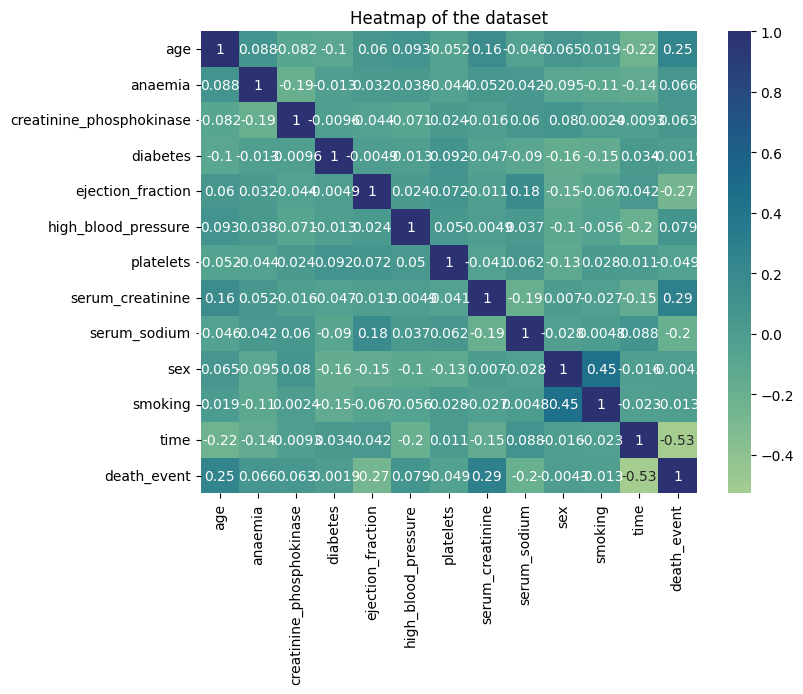

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


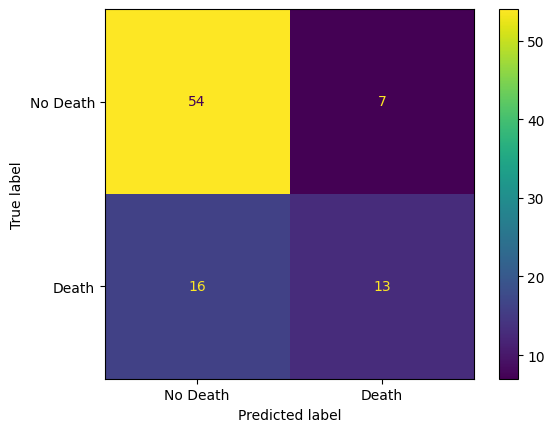

              precision    recall  f1-score   support

    No Death       0.77      0.89      0.82        61
       Death       0.65      0.45      0.53        29

    accuracy                           0.74        90
   macro avg       0.71      0.67      0.68        90
weighted avg       0.73      0.74      0.73        90



,Feature,Coefficient
0,age,2.977327e-02
1,anaemia,4.578999e-01
2,creatinine_phosphokinase,3.496661e-04
3,diabetes,3.485270e-01
4,ejection_fraction,-7.167514e-02
5,high_blood_pressure,4.771051e-01
6,platelets,-6.195693e-07
7,serum_creatinine,9.121805e-01
8,sex,-3.664759e-01
9,smoking,5.262307e-01


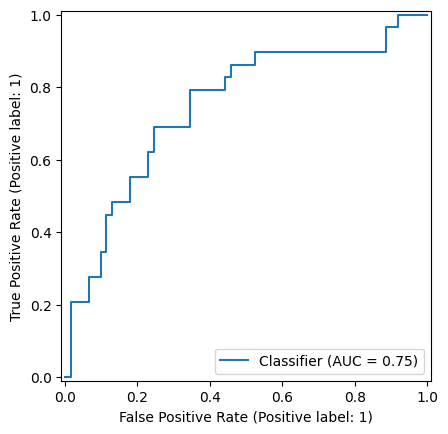

ROC-AUC: 0.746


In [48]:
# Correlation matrix to help determine most correlated variables
heart_failure_clinical_records.corr(numeric_only=True)

# Heatmap to visualize how correlated variables are
plt.figure(figsize=(8, 6))
sns.heatmap(
    heart_failure_clinical_records.corr(numeric_only=True),
    annot=True,
    cmap="crest")
plt.title("Heatmap of the dataset")
plt.show()

# Selecting features
X = heart_failure_clinical_records[[
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "sex",
    "smoking"
]]

y = heart_failure_clinical_records["death_event"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Fit logistic regression
log_clf = LogisticRegression(
    random_state=42,
    max_iter=800
)

log_clf.fit(X_train, y_train)

# Class predictions
y_pred = log_clf.predict(X_test)

# Predicted probability of death_event = 1
y_prob = log_clf.predict_proba(X_test)[:, 1]

# Confusion matrix
log_cm = confusion_matrix(
    y_test,
    y_pred,
    labels=log_clf.classes_
)

log_disp = ConfusionMatrixDisplay(
    confusion_matrix=log_cm,
    display_labels=["No Death", "Death"]
)

log_disp.plot()
plt.show()

# Classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Death", "Death"]
    )
)

# Model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_clf.coef_[0]
})

display(coefficients)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

# ROC-AUC
roc_auc = metrics.roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

### Logistic Regression – Model Evaluation

The baseline logistic regression model achieved an **accuracy of 74%** and a **ROC-AUC of 0.75** on the held-out test set.

Model performance differed considerably between the two outcome classes:

- **No Death:** precision = 0.77, recall = 0.89, F1-score = 0.82
- **Death:** precision = 0.65, recall = 0.45, F1-score = 0.53

The confusion matrix showed that **54 of 61 surviving patients** were correctly classified. However, only **13 of 29 patients who died** were correctly identified, while **16 deaths were incorrectly classified as survivors**.

The ROC-AUC of **0.75** indicates moderate discriminative ability: the model can distinguish patients with and without the mortality outcome better than chance, although substantial overlap between the two groups remains.

While the overall accuracy appears reasonable, the relatively low **recall for mortality (45%)** represents an important limitation. In a clinical risk-prediction setting, false-negative predictions may be particularly relevant because high-risk patients could remain unidentified.

Overall, logistic regression provides an interpretable **baseline model with moderate discriminatory performance**, but its current sensitivity for mortality would be insufficient for clinical application. Future model development should therefore focus on improving mortality detection and evaluating the trade-off between sensitivity and specificity.